In [10]:
pip install xgboost

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.1.3-py3-none-win_amd64.whl (72.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, anderson


#Grab data and put numerical vals in one table
#################################################################################################################
dataset_as_given = pd.read_csv(r"d:\Desktop\Practice Python\21.gym_members_exercise_tracking.csv")
#print(dataset_as_given)

# Get column names
column_names = dataset_as_given.columns
#print(column_names)

desired = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM", "Resting_BPM", 
           "Session_Duration (hours)", "Calories_Burned", "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)", "Experience_Level", "BMI"]

dataset_as_given_numeric = dataset_as_given[desired]



#Get Rid of Outliers
#################################################################################################################

# Copy the dataset so you keep the original intact
cleaned_df = dataset_as_given.copy()

# Select numeric columns
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]



print("Original rows:", dataset_as_given.shape[0])
print("Cleaned rows:", cleaned_df.shape[0])
print("Rows removed:", dataset_as_given.shape[0] - cleaned_df.shape[0])


#################################################################################################################

encoded_df = cleaned_df.copy()

encoded_df['Gender'] = encoded_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

workout_dummies = pd.get_dummies(encoded_df['Workout_Type'], prefix='Workout', drop_first=True)
encoded_df = pd.concat([encoded_df.drop(columns=['Workout_Type']), workout_dummies], axis=1)




Original rows: 973
Cleaned rows: 931
Rows removed: 42


In [2]:
# ============================================================
#   TRAIN/TEST SPLIT + SCALING
#   This prepares your data for any ML model
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Define X (features) and y (target)
# ------------------------------------------------------------
# Gender must already be encoded as 0/1 in encoded_df
X = encoded_df.drop(columns=['Gender'])
y = encoded_df['Gender']

# ------------------------------------------------------------
# 2. Train/Test Split
# ------------------------------------------------------------
# test_size=0.2 means 20% of data is held out for testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 3. Scale the numeric features
# ------------------------------------------------------------
# Scaling helps models like Logistic Regression, SVM, KNN, Neural Networks
# Tree-based models (Random Forest, XGBoost) do NOT require scaling,
# but scaling does not harm them.
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. Optional: Print shapes to confirm everything looks right
# ------------------------------------------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nScaled versions created: X_train_scaled, X_test_scaled")


X_train shape: (744, 16)
X_test shape: (187, 16)
y_train shape: (744,)
y_test shape: (187,)

Scaled versions created: X_train_scaled, X_test_scaled


K-Nearest Neighbor (KNN) Algorithm is a supervised machine learning algorithm that is generally used for classification but can also be used for regression tasks<br><br>

The algorithm works by finding the "K" closest data points (neighbors) to a given input and makes a prediction based on the majority class (for classification) ir the average value (for regression)<br><br>

This type of algorithm makes no assumption about the underlaying data distribution it makes it a non-parametric and instance based learning method<br><br>

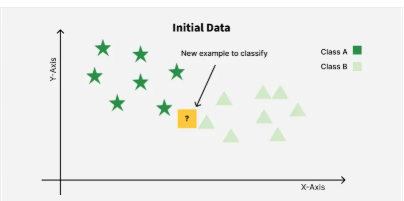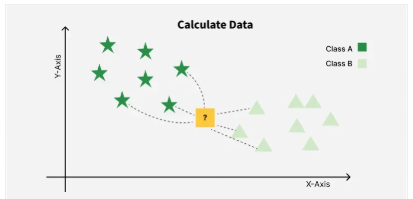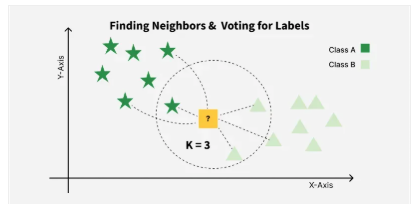<br><br>

K-Nearest neighbors is also called a lazy learner algorithm because it does not learn from the training set immediately - instead, it stores the entire dataset and performs computations only at the time of classification<br><br>

As an example - let us consider 2 features which will be called Category 1 and Category 2<br><br>

- KNN assigns the category based on the majority of nearby points -> the image below shows how KNN predicts the category of a new data point based on its closest neighbours<br><br>

- The green points represent Category 1 while the red points represent Category 2<br><br>

- The new datapoint checks its closest neighbours (circled points)<br><br>

- Since the majority of its closest neighbours are red points (belonging to Category 2) -> the model predicts that the new data point belongs to Category 2 as well<br><br>

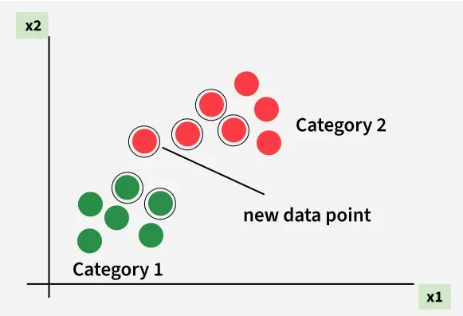<br><br>

The discussed type of model uses proximity and majority voting to make predictions<br><br>

The 'K' in K Nearest Neighbour is just a number that tells the algorithm how many nearby points or neighbours to look at when it makes a decision<br><br>

Example: We are trying to put a specific fruit in a category -> therefor we compare its shape and size to that of fruits that are already familiar to us<br>
- If K = 3 -> the algorithm looks at the closest 3 fruits to the new one<br>
- If 2 of those 3 fruits are apples and 1 is a banana, the algorithm says the new fruit is an apple because most of its neighbours are apples<br><br>

How is the value of K for the KNN Algorithm chosen?<br><br>

- The value of K in the algorithm decides how many neighbours the algorithm looks at when making a prediction<br><br>

- Choosing the correct K is important for good results <br><br>

- If the data contains lots of noise or outliers, using a larger K can make the predictions more stable<br><br>

- But if K is too large, the model can become too simple and miss important patterns and this is called underfitting<br><br>

- K should be picked carefully based on the existing data<br><br>

What are some possible Statistical Methods for Selecting K?<br><br>

- Cross-Validation -> this is a good way to find the best value of K using k-fold validation. For this to happen, the dataset will be devided into K parts, then the model will be trained on some of the parts and tested on the remainder of the parts. The process repeats itself for all of the parts. The K value that gives the highest value for accuracy during the tests - is normally the best k value to use<br><br>

- Elbow Methods -> for this method, a graph is drawn that shows the error rate or accuracy for various K values. As K increases, the error usually drops at first, and after a certain point the error stops decresing quickly. The point where the curve changes direction and looks like an 'elbow' is usually the best choice for K this method offers<br><br>

- Odd Values for K -> using an odd number for K is a good idea for classification problems. This method avoids ties when deciding which class is the mosr common among the neighbours<br><br>

Distance Metrics are used in the KNN algorithm. These can include:<br><br>

1. Euclidean Distance -> which is defined as a straight line distance between two points in a plane or space. This is the shortest path that can be walked from Point A directly to Point B<br><br>

2. Manhattan Distance -> this is the total distance you could walk from Point A to Point B if you could only walk along horizontal and vertical lines like a grid or city streets. This type of distance is also called the 'taxicab distance' because a taxi can only drive along the grid-like streets of a city<br><br>

3. Minkowski Distance -> this type of distance is like a familty of distances which includes both Euclidean and Manhattan distances as special cases. For the Minkowski distance, its formula is flexible and can represent either Euclidean or Manhattan distance depending on the inputted values<br><br>

How does the K-Nearest Neighbours algortihm work?<br><br>

The discussed algorithm operates on the principle of similarity where it predics the label or value of a new data point by considering the labels or values of its K nearest neighbours in the training dataset<br><br>

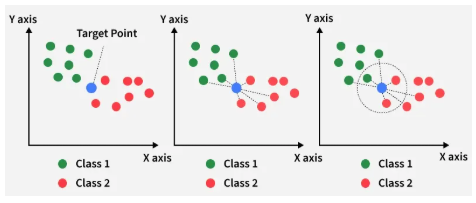<br><br>

Step 1: Select the optimal value for K<br>
K represents the number of nearest neighbours that needs to be considered while making predictions<br><br>

Step 2: Calculating the distance<br>
To measure the similarity between target and training data point - Euclidean distance is widely used. The distance is calculated between datapoints in the dataset and target point<br><br>

Step 3: Finding nearest neighbours<br>
The K data points with the smallest distance to the targer point are nearest neighbours<br><br>

Step 4: Voting for Classification or Taking Average for Regression<br>
-When you want to classify a data point into a category like Spam VS Not Spam, the KNN algorithm looks at the closest K points in the dataset. These closest points are called neighbours. The algorithm them looks at which category the neighbours belong to and picks the one that appears the most. This is called majority voting<br> 
-In regression, the algorithm still looks for the K closest points, but instead of voting for a class in classification, it takes the average of values of those K neighbours. This average is the predicted value for the new point for the algorithm<br><br>

Applications of KNN include:<br><br>

- Reccomandation Systems -> to suggest items like movies or products by finding users with similar preferences<br><br>

- Spam Detection -> to identify spam emails by comparing new emails to known spam and non-spam examples<br><br>

- Customer Segmenatation -> to group customers by comparing their shopping behaviours to other customers<br><br>

- Speech Recognition -> to match spoken words to known patterns to convert them into text<br><br>

Advantages of KNN include:<br><br>

- That the model is simple to use -> easy to understand and implement<br><br>

- There are no training steps -> there is no need to train as it just stores the data and uses it during prediction<br><br>

- It uses few parameters -> it only needs to set the number of neighbours (K) and a distance method<br><br>

- Versatility -> works for both classification and regression problems<br><br>

Disadvantages of the model include:<br><br>

- It is slow with large data -> needs to compare every point during prediction<br><br>

- Struggles with many features -> accuracy drops when data has too many features<br><br>

- Can overfit -> It can overfit especially when the data is high-dimensional and has not been cleaned<br><br>

https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/<br><br>

Machine Learning is a branch of Artificial Intelligence that focuses on developing models and algorithms that let computers learn from data without being explecitly programmed for every task. In simple words, Machine Learning teaches system to think and understand like humans by learning from data.<br><br>

Machine Learning is divided into 3 main types:<br><br>

- Supervised Laerning -> meaning that the model trains on labeled data to predict or classify unseen data<br><br>

- Unsupervised Learning -> finds patterns or groups in unlabeled data, like clustering or dimensionality reduction<br><br>

- Reinforcement Learning -> learns through trial and error to maximize reqards, ideal for decision-making tasks<br><br>

Note: The following two additional types of machine learning are not part of the original 3 core types of machine learning but they have become incresingly important in real-world applications, especially in deep learning:<br><br>

- Self-Supervised Machine Learning -> this type of machine learning is often considered to be a subset of unsupervised learning, but it has grown into its own field due to its success in training large-scale models. It generates its own labels from the data, without any manual lableling<br><br>

- Semi-Supervised Machine Learning -> this approach combines a small amount of labeled data with a large amount of unlabeled data. This method is useful when labeling data is time-consuming or expensive<br><br>

https://www.geeksforgeeks.org/machine-learning/machine-learning/<br><br>

Machine Learning Models should learn useful patterns from training data. When a model learn too much or too little, overfitting and underfitting happen.<br><br>

Underfitting -> means that the model is too simple and does not cover all the real patterns in the data<br><br>

Overfitting -> means that the model learns not just the underlying pattern, but also noise or random quircks in the training data -> the model ends up memorizing the data<br><br>

A good model -> finds the good spot that is complex enough to learn real patterns, but not so complex that it memorizes moise<br><br>

What is Underfitting?<br><br>

Underfitting happens when the model fails to learn important patterns. It performs poorly on both training and testing data. Underfitting can happen due to:<br><br>

- The model being too simple<br><br>

- Very high regularization<br><br>

- Features are weak or missing<br><br>

- Not enough training<br><br>

- High bias<br><br>

Bias: it is like assuming that all birds can only be small and fly, so the model fails to recognize big birds like ostrices or penguins that can not fly and become biased in its predictions -> bias can be when you make an assumtion about the data - or in this case the machine learning model makes an assumption about the data that because it does not see the full picture of things -> which can happen if one category that is included in the dataset appears a lot more than the other etc.<br><br>

Bias-Variance Inside Underfitting<br><br>

Underfitting mainly occurs to high bias:<br><br>

- Meaning that due to high bias, the model makes strong assumptions<br><br>

- It also ignores patterns<br><br>

- It learns an overly simple representation of the dataset<br><br>

- Variance is low because the model gives similar outputs even if the data changes<br><br>

Underfitting = High Bias + Low Variance<br><br>

What is Overfitting?<br><br>

Overfitting is mainly caused by high variance -> high variance means that the model reacts too strongly to the training data, learning noise as patterns. The dataset can also contain low bias because the model is extremely flexible<br><br>

Overfitting = Low Bias + High Variance<br><br>

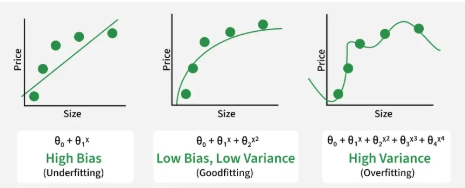<br><br>

As seen in the image:<br><br>

- Underfitting -> is represented by a straight line that is trying to fit a curved dataset but it can not capture the pattern of the data, leading to poor performance on both training and test sets<br><br>

- Overfitting -> represented by a squggly curve passing through all training points, failing to generalize -> the model would perform well on the training data but poorly on the test data<br><br>

- Appropriate Fittng -> represented by the line that follows the data trend without overcomplicating capturing the true patterns of the dataset<br><br> 

Bias-Variance Tradeoff<br><br>

The relationship between bias and variance is often referred to as the bias-variance tradeoff, which highlights the need for balance between the 2<br>
Increasing model complexity reduces bias but increases variance (risk of overfitting)<br>
Simplifing the model reduces variance but increases bias (risk of underfitting)<br><br>

The goal is to find an optimal balance where both bias and variance are minimized, resulting in good generalization performance<br><br>

Imagine predicting house prices based on size. You plot the data and try and draw a curve that represents the trend. How well this curve fits depends on the complexity of the model<br><br>

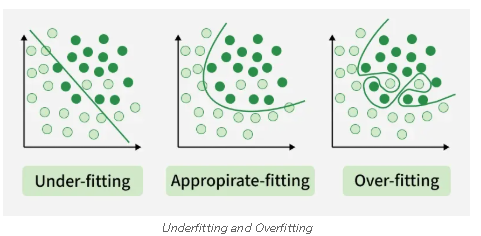<br><br>

Underfitting (High Bias) -> a model that is too simple is produced (like a straight line for curved data) -> which misses key patterns and performs poorly on both training and testing data<br><br>

Overfitting (High Variance) -> a model that is too compled is produced (like a high degree polynomial) -> which learns noise, fits training data too closely, and performs poorly on new data<br><br>

Ideal Fit (Balanced) -> a model that is moderately compled is produced -> which captures the main trend without following noise, giving good performance on both training and testing data<br><br>

How are Overfitting and Underfitting addressed?<br><br>

Techniques to Reduce Underfitting<br>
- Use a more complex model<br>
- Add new features amd perform feature engineering<br>
- Reduce Regularization<br>
- Train for more epochs<br>
- Scale features properly<br><br>

Techniques to reduce Overfitting<br>
- Collect more training data<br>
- Reduce model complexity<br>
- Use Regularization (L1/L2)<br>
- Apply dropout (for neural networks)<br>
- Use early stopping<br>
- Clean noisy data<br><br>

https://www.geeksforgeeks.org/machine-learning/underfitting-and-overfitting-in-machine-learning/<br><br>

What are Epochs in Machine Learning?<br><br>

When it comes to Machine Learning, the training data is almost nerver processed in a single pass. Instead, the data is shown to the model multiple times so it can gradually refine its parameters. An epoch referes to 1 complete pass over the entire training set. For instance, with a dataset of 1 million images, one epoch means that the model has seen each image once. <br><br>

Within one epoch, training happens in batches. Each batch updates the model's internal parameters - its weights and biases - based on computed gradients. The first epoch mainly helps the model get oriented, while subsequent epochs allow it to capture more stable and meaningful patterns. <br><br>

Every additional epoch given the network another opportunity to fine-tune its weights, improve accuracy and reduce error. But more is not always better in this case as after a point, the model may stop learning generalizable patterns and begin overfitting by memorizing noise in the data. This is where the question of how many epochs for fine-tuning becomes important - you want enough cycles for effective adaptation, but not so many that generalization is lost. <br><br>

In practice, epochs act as units of progress. Temas monitor metric epoch by epoch -> looking at whether accuracy is improving, whether loss continues to drop and when validation error starts to rise. Those trends reveal both, how many epochs were genuinely useful, and when training should have stopped. <br><br>

How many enough is enough?<br><br>

There is no universal answer. The optimal number depends on dataset complexity, model architecture and quality requirements. An epoch itself consits of many steps. Each step processes a batch, computes gradients and updates weights. With 50000 examples and a batch size of 100, one epoch equals 500 steps. <br><br>

When augmentationgs are applied, each pass may expose the model to different versions of the same sample. In distributed training, shards are split across devices -> the definition of an epoch is tied to the sampler, but collectively the system stil processes the full dataset once. <br><br>

Epochs are also natural checkpoints. They define moments for running validation, saving weights, adjusting learning-rate schedules and analyzing metric curves. If loss plateaus or validation accuracy stops improving, additional epochs add little value.<br><br>

In short, epochs do not just mark time, they shape experimentation, cadence, and evaluation.<br><br>

How many epochs is too many?<br><br>

In theory, reaining can run indefinetly; more epochs simply mean more full passes through the data. In practice, returns diminish quickly. After a certain point, additional epochs do not improve generalization. Instead, the model adapts too closely to the training data - a classic case of overfitting.<br><br>

The clearest signal comes from learning curves -. training accuracy keeps rising, while validation accuracy falls or validation loss climbs. At that stage, more epochs not only fail to help but actively degrade performance.<br><br>

The standard safehuard is ealry stopping. Training halts automatically if validation metrics fail to imporve over a ser window. The best-performing checkpoint is preserved, ensuring the final model corresponds to peak validation quality. Other factors affect overfitting dynamics. A high learning rate can accelarate memorization and trigger earlier overfitting. Stronger regularization or heavy augmentation slow it down, allowing safe tranining across more epochs. The right balance emerges from the interaction of epoch count wiht these settings, not from epoch count alone. <br><br>

Finally, training lenght has an aconomic cost. Every extra epoch consumes GPU hours, increases experimentation latency and raises infrastructure spend. Overtraining carries a double penalty: wasted resources and degraded quality. Keeping epoch count under control is therefor both a scientific and operational necessity.<br><br>

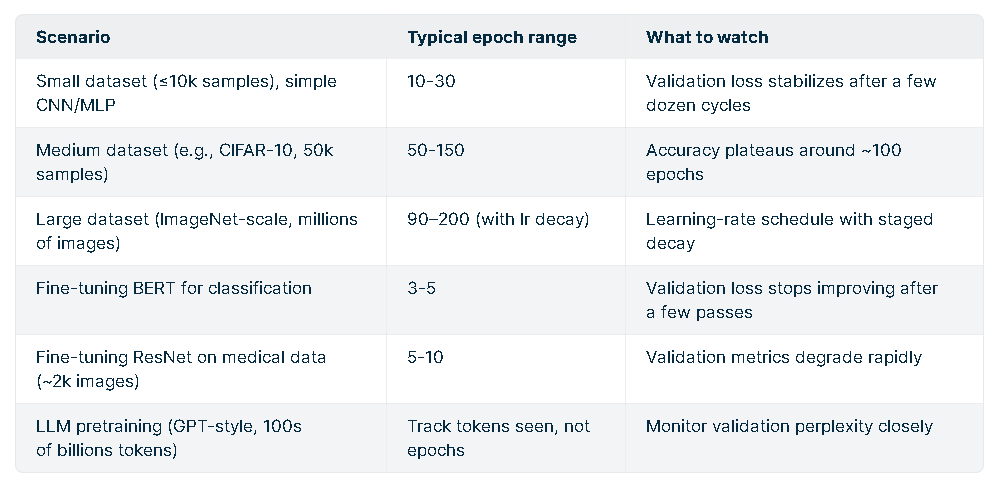<br><br>

How many epochs are needed to fine-tune pretrained models?<br><br>

Fine-tuning pre-trained models typically requires far fewer epochs than training from scratch. The base model already cantains useful representations, so the focus is on adaptation rather than relearning everything. <br><br>

In practice, many NLP and vision tasks converge within 2 to 10 epochs. For example, BERT-based classification typically sees most improvements in the first few passes. In vision tasks, adaptation can be even faster, especially when only the top layers are trained while lower-level features remain frozen. <br><br>

The scale and domain of the dataset also play a kew role. Small datasets, such as those used in medical or highly specialized applications, tend to overfit quickly. Larger, domain-specific corpora, like legal documents or technical manuals, may require more passes to alighn the model's internal representations with the task at hand. <br><br>

The number of trainable layers further influences epoch needs. When most parameters are frozen, only a few epochs are sufficient. If multiple layers are unfrozen, more parameters are updated, requirings longer training, but this also increses the risk of eroding the knowledge embedded in the pretrained base.<br><br>

For these reasons, fine-tuning demands careful monitoring. Prolonged training often harms more than it helps, degradig both validation performance and the pretrained model's general knowledge. Stopping at the right moment ensures the model apapts effectively while preserving its foundational strenghts.<br><br>

How many batches per epoch?<br><br>

An epoch represents a full pass through the training dataset and is divided into steps that iterate over mini-batches. The number of steps in an epoch is calculated as int(N/V), where N = dataset size and B = batch size.<br><br>

Batch size influences not only the number of steps but also the learning dynamics. Smaller batches create noisier gradients, which can help the model avoid sharp minima and sometimes improve generalization. Larger batches, on the other hand produce smoother gradients and speed up convergence, but without careful adjustemnts, such as linear learning rate scaling, warm-up schedules, or strong regularization, they may reduce generalization quality.<br><br>

The number of batches per opoch is therefor shaped not only by the dataset size but also by available computations resurces. A larger batch size reduces the number of iterations and shortens each epoch, but it requires more memory and careful optimizer tuning. Smaller batches lenghten training in terms of epochs, yet each iteration is lighter and often provides more stable validation behaviour.<br><br>

Ultimately, the number of batches per epoch is not an isolated decision - it follows directly from the chosen batch size and training strategy. In practice, engineers balance between efficiency and generalization, selecting a batch size that maximizes hardware usage while maintaining stable validation performance.<br><br>

The number of epochs is not a fixed parameter; it emerges from the interaction of multiple aspects of training. On large datasets, a network needs longer to absorb the underlying statistics, often requiring tens or even hundreds of passes. On small datasets, however, running too many epochs quickly leads to memorization of noise, with metric improvements dissapering after only a few iterations. Data quality also plays a decisive role: mislabeled or noisy samples reduce the benefit of additional epochs, since the model begins fitting artifacts rather than extracting meaningful patterns.<br><br>

Model architecture further shapes convergence speed. Smaller networks with fewer parameters tend to plateau quickly, while deeper or transformer-based models often measure progress not in epochs but in tokens processed or optimization steps. In streaming scenarios, such as training on massive web-scale corpora, the very idea of an epoch becomes less rigid, and progress is monitored mainly through validation curves. For fine-tuning such models, only a handful of adaptation cycles are typically enough to steer pretrained representations towards a new task. <br><br>

Learning rate is another decisive factor. Higher rates accelerate convergence and may reach peak performance within fewer epochs, though they also increase the risk of oscillations or instability. Lower rates ensure steadier reductions in error but demand more iterations. In this way, optimization choices direcly infuence how many epochs are necessary to achieve stable results.<br><br>

Regularization also alters the balance. Dropout, weight decay and strong augmentation improve robustness but slow down convergence, often requiring more epochs to recover performance. To compensate, adaptive learning rate schedules are frequently paired with these methods.<br><br>

Finally, the stopping strategy determines the actual endpoint. Early stopping and dynamic learning rate adjustments allow training to conclude as soon as validation metrics stop improving. Here, the question shifts from 'how many epochs are needed' to 'at which step does the model reach peak validation performance?'.<br><br>

In real-world projects, all these factors combine: dataset scale and quality, network depth, optimizer hyperparameters and regularization strategies collectively determining how long training should run. No single variable sets the epoch count; rather, it is the interplay of all these elements that defines the optimal stopping point.<br><br>

What are the best practices for choosing the correct number of epochs?<br><br>

Defining the right number of epochs in advance is nearly impossible. Even tasks that look similar can behave very differently, and what works for one model may fail for another. The most effective approach is to use a flexible training strategy.<br><br>

A good strating point is to train for just a few epochs to quickly see how the model behaves. At this stage, plotting loss and accuracy curves is essential, as they show whether performance is improving and how fast. If validation metrics keep rising after five to ten epochs, the training run can be extended.<br><br>

To avoid wasting resources, most setups use early stopping. This technique halts training if performance does not improve for several epochs in a row. Often, a patience patameter is added: the model is not stopped immediately at the first plateau but given a few chances to escape a local minimum.<br><br>

Another useful practice is applying dynamic hyperparameter schedules. For example, lowering the learning rate once the error curve stabilizes can help the model reach better results without endlessly adding more epochs.<br><br>

In large-scale projects, automated hyperparameter tuning frameworks such as Optuna or Ray Tune are widely used. These tools can run dozens of experiments in parallel with different epoch counts, learning rates and regularization settings. They save weeks of manual trial and error and deliver more reliable results. <br><br>

In the end, choosing epochs is not about picking a single number, but about setting up a process where the model itself shown you when it is time to stop.<br><br>

As a Conclusion<br><br>

Epochs are not a fixed parameter but a flexible setting shaped by data size, model architectire and training strategy. A simple network may converge in ten epochs, while a large model trained on complex datasets might require hundreds of passes. <br><br>

The key is not to rely on present numbers but to monitor validation metrics. Once they plateau or decline, the model has likely reached its optimal point. Training beyond this often wastes resources and raises the risk of overfitting. That said, advanced scheduling strategies can sometimes push performance further.<br><br>

Practical tools like early stopping, dynamic learning rate schedules and automated hyperparameter tuning make training both efficient and reproducible. For ML engineers managing production infrastructure, this is critical -> every extra epoch consumes GPU hours, cluster time and budget. Finding the right balance saves costs while maintaining accuracy.<br><br>

In the end, the question 'how many epochs are needed?' has no single answer - but there is a universal approach -> track the training curves, watch when metrics stabilize and stop at peak validation performance. This is how real-world machine learning teams achive both model quality and operational efficiency.<br><br>

https://nebius.com/blog/posts/epochs-in-day-to-day-ml-pipelines<br><br>

What is the difference between a shaprm minimum and a flat minimum in a loss landscape? -> in the context of training neural networks<br><br>

Understanding the Loss Landscape<br>
First, a quickly recap. The 'loss landscape' (or 'error surface') is a visualizatio of the loss function of a machine learning model. Think of it as a hilly terrain<br><br>

Loss function -> This function takes the model's parameters (weights and biases) as input and outputs a value representing how 'wrong' the model's predictions are. The goal of training is to find the parameters values the minimize this loss. <br><br>

Parameters -> These are the adjustable knobs and dials of your model.<br><br>

Minima -> These are the 'valleys' in the landspace - points where the loss function has a low value. Ideally, we want to find the minimum.<br><br>

1.Sharp (Narrow) Minima<br>
Definitions -> A sharp minimum is a region in the loss landscape where the loss if very low, but only for a very specific set of parameter values. It is like a deep, narrow valley. A small change in the parameters can lead to a significant increase in the loss.<br><br>

Characteristics -> <br><br>

Steep Gradient -> Around a sharm minumum, the gradient (the direction of the steepest ascent) is very large. This means the optimization algorithm (like gradient descent) will move quickly and dramatically to reach this minimum. <br><br>

Poor Generalization -> This is the big problem. Models that converge to sharm minima tend to overfit the training data. They have esentially memorized the training examples rather than learning the underlaying patterns, They perform well on the training data but poorly on useen data (the validation/test set).<br><br>

Sensitive to Initizalization -> The starting point of the optimization process (the initial values of the parameters) can heavily influence whether the algorithm finds a sharm minimum. Different initializations can lead to very different final results. <br><br>

Analogy -> Imagine a perfectly carved, narrow bowl. If you place a marble in it, it will settle at the bery bottom, but if you nudge it even slightly, it will roll out.<br><br>

2.Flat (Wide) Minima<br>
Definition -> A flat minimum is a region in the loss escape where the loss is low, and a wide range of paramaters values result in a similar low loss. It is like a broad, shallow valley<br><br>

Characterustics -> <br><br>

Gentle Gradient -> Around a flat minimum, the gradient is small. The optimization algorithm moves more slowly and gradually<br><br>

Good generalization -> Models that converge to flat minima tend to generalize better to unseen data. They have learned more roboust, underlaying patterns that are not specific to the training dataset<br><br>

Less sensitive to initialization -> The starting point of the optimization process is less critical. The algorithm is more likely to find a good solution regardless of where it starts<br><br>

Analogy -> Imagine a wide, gently slopping bowl - if you place a marble in it, it can be nudged a bit without rolling out.<br><br>

Here is a table summarizing the key differences:<br><br>

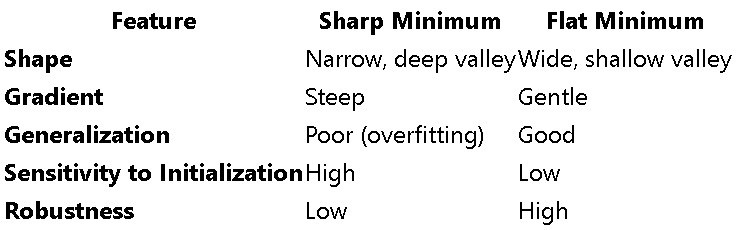<br><br>

Why is it important?<br><br>

Optimization Challanges -> It is often difficult to intentionally find flat minima. Standard gradient descent can easily get stuck in sharp minima. <br><br>

Regularization -> Techniques like L1/L2 regularization, dropout, and data augmentation are often used to encourage the model to find flatter minima. They effectively 'smooth out' the loss landscape, making it more likely to find broader, more generalizable solutions.<br><br>

Batch Size -> Smaller batch sizes during training can sometimes lead to flatter minima, while larger batch sizes can lead to sharper minima. <br><br>

Optimization Algorithms -> More advances optimization algorithms (like Adam, SGD with momentum) can sometimes heap escape minima and find flatter regions. <br><br>

In essence, the goal in training machine learning models to find a flat minumum in the loss landscape, as this leads to better generalization and a more robust model. <br><br>


https://www.truegeometry.com/api/exploreHTML?query=What%20is%20the%20key%20difference%20between%20a%20sharp%20minimum%20and%20a%20flat%20minimum%20in%20a%20loss%20landscape<br><br>

What is an epoch in Machine Learning?<br><br> (will go over whole article simply to reitarate and get it settled even more in my brain)

Machine Learning is the science of developing algorithms that perform tasks without explicit instructions. These algorithms use statistical models to identidy patterns in existing data and make an inference or prediction for new data. For example, ML models analyse an existing data set of prelabbeled cat and dog images. Then, they predict wheather a previously unknown image (not found in the initial training set) is a cat or a dog.<br><br>

Most Machine Learning models are internally made of neural networks. Neural networks are layers of interconnected software components called nodes that work together to process data. Each node looks at different data aspects or features - like eye shape, ear shape, or nose shape and performs mathematical calculations. Results from individual nodes are combined to find the final solution.<br><br>

You must understand the training process to learn more about machine learning and neural networks. <br><br>

What is an epoch?<br><br>

An epoch in machine learning occurs when the machines learning model completes one pass through the training dataset. You can think of this process as going through your entire study meterial once. Every time you read to learn, you complete an epoch in machine learning terms. <br><br>

Data engineers repeatedly feed the same training data to the model so it can identify new patterns and gain a deeper understanding of the data. After every epoch, the model updates its internal mathematical calculations based on the data it was just fed. It mainly adjusts weights and biases, mathematical factors that determine how different neurons affect each other's output.<br><br>

What happends in an epoch?<br><br>

Here is a closer look at what occurs during an epoch<br><br>

- Forward pass -> Each sample in the training dataset is passed through the network to compute the output. This involved using the current values of the network's wieghts and biases to calculate the output for each input sample<br><br>

- Loss Calculation -> After the input is obtained, a loss (or cost) function calculates the prediction error by comparing it to the expected output. This error provides a measure of the network's performance<br><br>

- Backward pass -> The error is then propagated back through the network, updating the weights and biases. This step is critical as it helps to minimize the loss by adjusting the model parameters (weights and biases)<br><br>

- Parameter Update -> The weights and biases are updated. The specific adjustments are determined by the gradients of the loss function with respect to each parameter<br><br>

Number of epochs<br><br>

It is important to metion that the number of epochs needed for model training can vary and is set by the data engineer. In most cases, it depends on the data's complexity and the desired accuracy level. This means traininng can run for tens, hundreds, or even thousands of epochs until the model generates accurate predictions for new data<br><br>

Generally, increasing the number of epochs leads to better model performance because it learns more complex patterns in the data. But be careful; too many epochs may cause the model to overfit! Accuracy drops if the unknown data is too different from the training dataset. For example, if the training data contained only images of cats and dogs in a park, the model may not be able to identify a can on a beach<br><br>

Batch, batch size, iteration<br><br>

A batch is a smaller portion of the entire training dataset. A large training dataset is usually split into smaller groups called batches or mini-batches for efficient model training. The model can process data in smaller chunks without problems like insufficient storage space. The batch determines how many samples will pass before updating the model's weights. <br><br>

The batch size shows the number of training examples in a single batch. For example, 10,000 data samples can be divided into ten batches of batch size 1000. The process of breaking down the dataset is called batch processing.<br><br>

Iteration<br><br>

Every time an algorithm processes a batch, it updates its internal parameters based on that data in preparation for the next batch. This update helps the model improve its performance on the learning task and reduce errors. This is also called an iteration. Multiple iterations make up an epoch.<br><br>

If: <br><br>

-> N = Total Number of Examples <br><br>

-> B = Batch Size <br><br>

-> I = Iteration <br><br>

Then: <br><br>

-> I = N/B<br><br>

-> In 1000 samples of batch size 1000, I = 10000/1000<br><br>

-> Therefor, I = 10<br><br>

-> Therefor, it will take 10 iterations to perform an epoch<br><br>

What is the difference between epoch and batch?<br><br>

A batch is a subsection of the complete training dataset. The quantity of samples in each batch is the batch size. On the other hand, an epoch is when all batches complete one pass through the algorithm.<br><br>

Difference between epochs and batch in a table:<br><br>

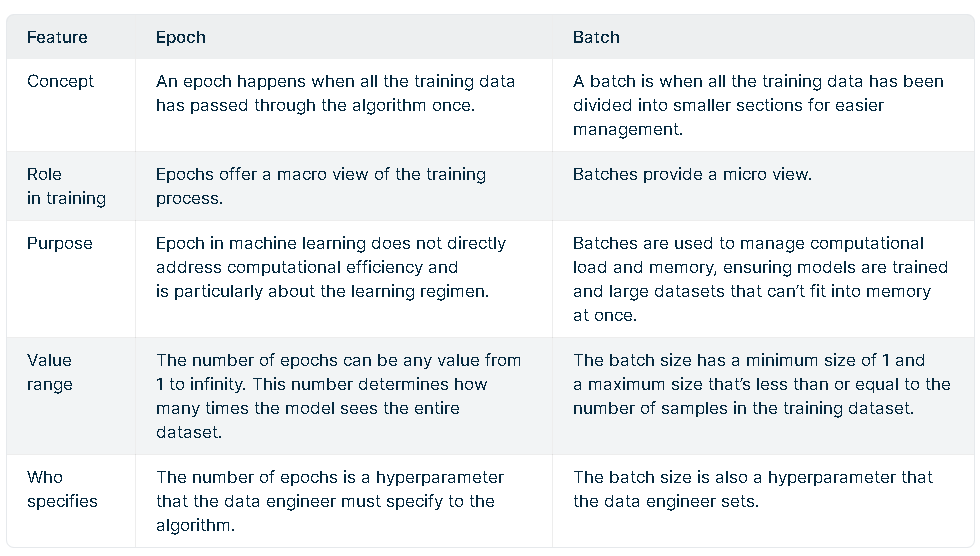<br><br>

How are paramteres updated in an epoch?<br><br>

Parameters are updated when a batch is processed. There are 3 models batch processing:<br><br>

-> Batch Mode -> The entire training dataset is considered a single batch (B=N). This means the model processes the entire dataset at once before updating its internal parameters<br>
              -> One majour advantage of this type of batch processing is that the model can reach convergence (optimal performance) in fewer epochs than other modes<br>
              -> On the flip side, this type of processing is computantionally expensive, particularly for complex models. It will also require a lot of memory to hold the entire dataset. There are also no frequent parameter updates, unlike other modes<br><br>

-> Mini-batch Mode -> This is the most common type of batch processing where the training data is broken down into smaller, manageble groups called mini-batches. The model processes one mini-batch at a time and updates its parameters after each mini-batch. <br>
                   -> With the mini-batch mode, you will rarely run into memory usage problems, meaning more speed. There is also potential for more frequent parameter updates. However, it will require more epochs to converge. You may also need to experiment a few times to find the optimal mini-batch size<br><br>

-> Stochastic Mode -> The stochastic mode uses unique batch sizing, which means the gradient and parameters are changed after each sample. Stochaistic gradient descent (SGD) is the optimization algorithm used to identify the set of internal model parameters that yield the closest match between predicted and actual outputs<br>
                   -> The SGD algorithm leverages the concept of an error gradient to achieve convergence. This esentially means it follows the slope of the error surface with respect to model parameters. It guides the parameter optimization process towards the minimum error level by iteratevly descending this slope. Predictions are generated at each step using a speicific sample and the current parameter set. The dicrepancy between predictions and expected results is quantified as the error. Subsequently, the internal parameters are adjusted to minimize this error in the next iteration <br><br>

Example of epochs in Machine Learning<br><br>

To better understand the concept of an epoch in machine learning, let's quickly discuss a specific example of mini-batch processing. Let's imagine you are training a model to predict movie ratings. Your entire dataset has information on 5000 movies (samples) with details like genre, cast, producer, and director. You could set the training to run for 20 epochs and choose a batch size of 100. <br><br>

Things would work out like this:<br><br>

In the first epoch, the data is shuffled and then split into 50 batches of 100 movies each. The model takes each batch, analyzes the features of the 100 movies, compares its predictions to actual ratings, and adjusts its internal weights. Thus, the model adjusts its weights 50 times across all 50 batches or iterations.<br><br>

Then data engineers shuffle the data, batch it again, and repeat the training process for 19 more epochs. By the end, the model has been exposed to the entire dataset 20 times (completing 20 epochs). During this process, its weights were updated a total of 1000 times as 50 batches/epochs X 20 epochs = 1000 iterations. <br><br>

Why is epoch essential in machine learning?<br><br>

Epochs are important when training machine learning models. An epoch helps to identfy the model that best fits the training data. Here are a few more reasons why this is a crucial concept in ML;<br><br>

- Improved Model Performance -> The number of epochs is an essential hyperparameter during training. Setting too few epochs can cause underfitting, where the model does not accurately learn the patterns in the data. On the flip side, too many epochs can lead to overfitting, where the model does not adequetly learn the patterns in the data. On the flip side, too many epochs can lead to overfittingm where the model become overly tuned to the training data's noise, underlying patterns without memorizing noise by choosing the right number of epochs. <br><br>

- Simplifying Early Stopping -> Monitoring performance metrics across epochs is important for techniques like early stopping. This method halts training when the model's performance on a validation set stops improving or starts to decline. Early stopping can also prevent overfitting and save computational resources.<br><br>

- Better insights into learning dynamics -> As epochs progress, users often get more valuable insights into the model's learning dynamics. For example, by observing how quickly the model learns and when it begins to plateau, users can make informed decisions about adjuting the learning rate, batch size, and other model parameters to improve performance.<br><br>

https://nebius.com/blog/posts/epoch-in-machine-learning<br><br>

https://medium.com/@mplai/the-mathematics-of-epochs-in-machine-learning-without-the-math-jargon-887fc95596a1<br><br>

Is convergence bad or good in models?
learning rate, batches, regularization, training
What types of optimization algorithms are there?

In [5]:
# ============================================================
# K-NEAREST NEIGHBORS (KNN)
# Looks at the 'closest' data points. Needs scaling.
# Look for performance drop if dataset is high-dimensional.
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.946524064171123


Accuracy: 0.9465

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        94
           1       0.97      0.92      0.95        93

    accuracy                           0.95       187
   macro avg       0.95      0.95      0.95       187
weighted avg       0.95      0.95      0.95       187



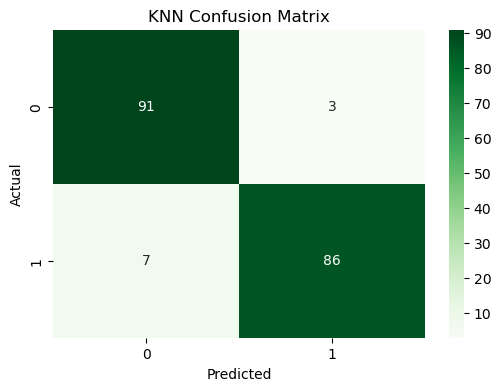

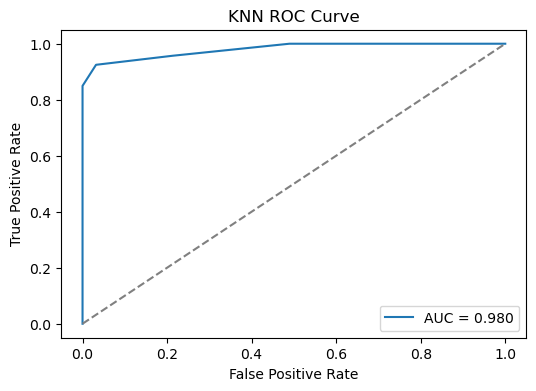

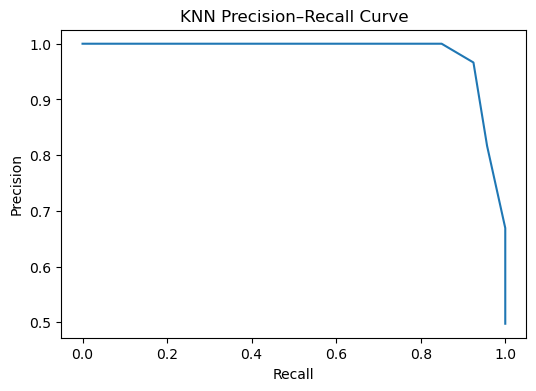


Average distance to 5 nearest neighbors: 2.5601
Lower values mean the data clusters well (good for KNN).


In [15]:
# ============================================================
#   K-NEAREST NEIGHBORS (KNN) — FULL MODEL EVALUATION
#   This cell trains the KNN model and evaluates it using:
#     ✔ Accuracy
#     ✔ Classification Report
#     ✔ Confusion Matrix
#     ✔ ROC Curve + AUC
#     ✔ Precision–Recall Curve
#     ✔ Distance-based intuition (unique to KNN)
#   Every section includes comments explaining what to look for.
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import numpy as np

# ------------------------------------------------------------
# 1. Train the KNN model
# ------------------------------------------------------------
# KNN relies heavily on distances between points.
# Scaling is CRITICAL — without it, features with large ranges dominate.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]  # needed for ROC/PR curves


# ------------------------------------------------------------
# 2. Accuracy Score
# ------------------------------------------------------------
# Accuracy = proportion of correct predictions.
# KNN can struggle in high-dimensional datasets.
accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy:.4f}")


# ------------------------------------------------------------
# 3. Classification Report
# ------------------------------------------------------------
# Shows precision, recall, and F1-score for each class.
# Look for balanced values across both classes.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


# ------------------------------------------------------------
# 4. Confusion Matrix
# ------------------------------------------------------------
# Shows EXACTLY where the model is making mistakes.
# Diagonal = correct predictions.
# Off-diagonal = errors.
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ------------------------------------------------------------
# 5. ROC Curve + AUC Score
# ------------------------------------------------------------
# ROC curve shows how well the model separates the two classes.
# AUC close to 1.0 = excellent.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.title("KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 6. Precision–Recall Curve
# ------------------------------------------------------------
# Useful when one class is less common.
# Look for curves that stay high (good precision)
# and far right (good recall).
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_knn)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("KNN Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# ------------------------------------------------------------
# 7. Distance-based intuition (unique to KNN)
# ------------------------------------------------------------
# KNN predictions depend on the distances to the nearest neighbors.
# We can inspect the average distance to the 5 nearest neighbors.
# Lower distances = tighter clusters = easier classification.
distances, indices = knn.kneighbors(X_test_scaled)

avg_distance = np.mean(distances)
print(f"\nAverage distance to 5 nearest neighbors: {avg_distance:.4f}")
print("Lower values mean the data clusters well (good for KNN).")
